# Lesson 4 — Where data comes from: sampling & study design

*Part 1 · Lesson 4 of 20  ·  data: simulation + a known population*

**←** [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 5: Probability & conditional probability](05-probability.ipynb) **→**

Every statistic you'll ever read — a poll, a drug trial, an "average price" — is only as
trustworthy as **how the data was collected**. This lesson is about that hidden step. We'll do
something most courses only *describe*: we'll take a full dataset, declare it the **population**
(so we actually *know* the true answer), then watch a good sampling method find that answer and a
biased one **miss it on purpose** — no matter how much data we throw at it.

The punchline you'll see with your own eyes: **a bigger sample does not fix a biased method.**

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sl.use_course_style()
rng = np.random.default_rng(7)   # fixed seed -> reproducible; change it to reshuffle the luck

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)
print(f'{len(ames):,} homes, {ames.shape[1]} columns')
ames[['area', 'price']].head()

2,930 homes, 82 columns


,area,price
0,1656,215000
1,896,105000
2,1329,172000
3,2110,244000
4,1629,189900


## 1) The four words: population, sample, parameter, statistic

These four words are the whole vocabulary of inference. Pin them down once and the rest of the
course is easier.

- **Population** — *everyone/everything* you actually care about (all the homes in Ames).
- **Sample** — the smaller group you actually measure (the 50 homes you had time to visit).
- **Parameter** — a number describing the **population**. Usually *unknown*. We write the true mean as $\mu$ (mu).
- **Statistic** — a number computed from your **sample**, used to *estimate* the parameter. We write the sample mean as $\bar{x}$ (x-bar).

A handy memory hook: **p**opulation goes with **p**arameter; **s**ample goes with **s**tatistic.

> **The whole game of statistics:** you can almost never measure the whole population, so you take
> a sample, compute a statistic $\bar{x}$, and use it to guess the parameter $\mu$. Everything that
> follows — bias, confidence intervals, hypothesis tests — is about *how good that guess is*.

### Our trick: treat the whole file as the population

In the real world $\mu$ is unknowable — you'd have to measure every home on Earth. So we play a
game: we **declare the entire Ames file to be the population.** Now $\mu$ is just a number we can
compute, which means we can *grade* any sampling method by how close its $\bar{x}$ lands to the
truth. We'll use **living area (square feet)** — a continuous, right-skewed variable.

Population size   N   = 2,930 homes
TRUE mean         MU  = 1499.7 sq ft   <- the answer every method will try to hit
TRUE median           = 1442.0 sq ft


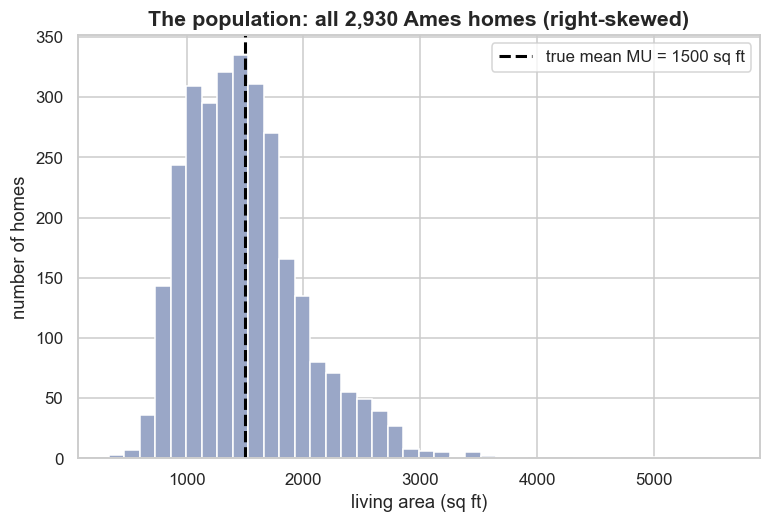

In [2]:
population = ames['area'].dropna().to_numpy()   # the WHOLE file is our population
MU = population.mean()                           # the TRUE parameter (we get to know it!)
N_POP = len(population)
print(f'Population size   N   = {N_POP:,} homes')
print(f'TRUE mean         MU  = {MU:.1f} sq ft   <- the answer every method will try to hit')
print(f'TRUE median           = {np.median(population):.1f} sq ft')

fig, ax = plt.subplots()
ax.hist(population, bins=40, color='#9aa7c7', edgecolor='white')
ax.axvline(MU, color='black', lw=2, ls='--', label=f'true mean MU = {MU:.0f} sq ft')
ax.set_xlabel('living area (sq ft)'); ax.set_ylabel('number of homes')
ax.set_title('The population: all 2,930 Ames homes (right-skewed)')
ax.legend(); plt.show()

## 2) Ways to draw a sample (in plain English)

Not all samples are made equal. Here are the methods you'll meet, from gold-standard to garbage:

| Method | How it works | One-line takeaway |
|---|---|---|
| **Simple random sample (SRS)** | every member has an *equal* chance; pick at random | the gold standard — no favoritism |
| **Stratified** | split the population into groups (*strata*), take an SRS *within each* | guarantees every group is represented |
| **Cluster** | split into groups, pick a few *whole groups* at random, measure everyone in them | cheaper when groups are spread out (e.g. whole towns) |
| **Systematic** | order the list, pick every $k$-th one (every 10th home) | easy; fine *if* the list order isn't sneaky |
| **Convenience** | grab whoever/whatever is easiest | fast and **biased** — avoid for real conclusions |

The first four use **randomness** in some principled way. The danger is the last one — and, more
subtly, *any* scheme where some members are systematically more likely to be picked than others.
That's what the next section makes visible.

In [3]:
# A simple random sample (SRS): every home equally likely, no replacement.
n = 50
srs = rng.choice(population, size=n, replace=False)
print(f'One SRS of n={n}:  sample mean x-bar = {srs.mean():.1f} sq ft')
print(f'True mean MU                          = {MU:.1f} sq ft')
print(f'Miss this time                        = {srs.mean() - MU:+.1f} sq ft  (pure luck of the draw)')

One SRS of n=50:  sample mean x-bar = 1531.3 sq ft
True mean MU                          = 1499.7 sq ft
Miss this time                        = +31.6 sq ft  (pure luck of the draw)


One sample tells us little — its miss is just luck. The honest question is: **if we repeated the
sampling method thousands of times, where would the sample means land?** That cloud of possible
$\bar{x}$ values is called the **sampling distribution**, and it's how we tell a *good* method from
a *biased* one.

## 3) THE key simulation — unbiased vs. biased sampling

Here is the heart of the lesson. We'll build two sampling machines:

1. **SRS** — pick 50 homes completely at random.
2. **Biased ("convenience")** — pick 50 homes, but **favor the bigger, fancier ones**. Imagine an
   agent who only bothers to measure impressive houses, or a website where large listings get more
   clicks and end up in the data. Every home *can* appear, but big ones appear far more often.

We run each machine **3,000 times** and collect the 3,000 sample means. A method is **unbiased** if
its sample means center on the true $\mu$; it is **biased** if they systematically land off to one
side.

In [4]:
# One simple random sample mean: everyone equally likely.
def srs_mean(n):
    return rng.choice(population, size=n, replace=False).mean()

# One CONVENIENCE-style biased sample mean: bigger homes are far more likely to be
# picked. We weight each home by its size raised to a power, so large homes dominate
# the draw -- mimicking 'only measuring the impressive houses' (selection on the variable).
# We draw WITH replacement, so the biased process behaves like an endless stream that keeps
# over-picking big homes no matter how much data we gather -- which is the whole point: the
# bias comes from the METHOD, not from running out of houses.
def biased_mean(n, strength=3.0):
    weights = population ** strength
    weights = weights / weights.sum()
    return rng.choice(population, size=n, replace=True, p=weights).mean()

REPEATS = 3000
srs_means    = np.array([srs_mean(50)    for _ in range(REPEATS)])
biased_means = np.array([biased_mean(50) for _ in range(REPEATS)])

print(f'TRUE mean  MU                 = {MU:.1f} sq ft')
print(f'SRS    sample means: average  = {srs_means.mean():.1f} sq ft   (off by {srs_means.mean()-MU:+.1f})')
print(f'BIASED sample means: average  = {biased_means.mean():.1f} sq ft   (off by {biased_means.mean()-MU:+.1f})')

TRUE mean  MU                 = 1499.7 sq ft
SRS    sample means: average  = 1498.3 sq ft   (off by -1.4)
BIASED sample means: average  = 2120.6 sq ft   (off by +620.9)


The SRS average of averages sits right on $\mu$ — that's what **unbiased** means. The biased
machine's averages sit far to the right of $\mu$: it overestimates the typical home size *every
time, on average*. Let's see both sampling distributions side by side.

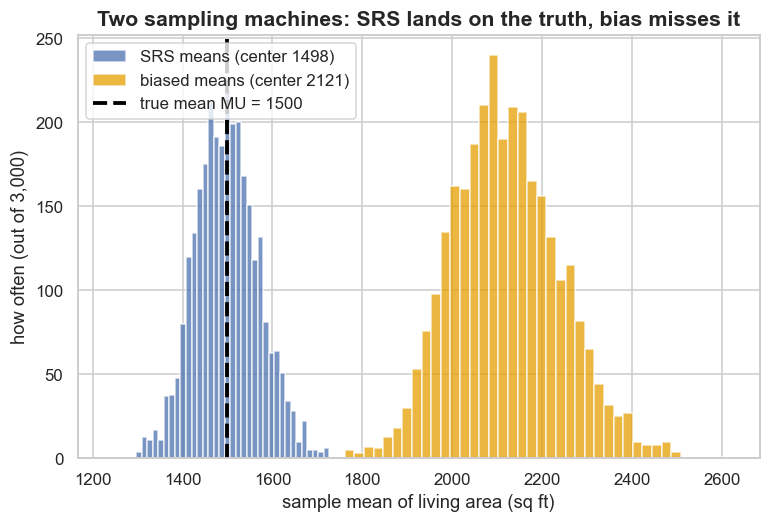

In [5]:
fig, ax = plt.subplots()
ax.hist(srs_means,    bins=40, alpha=0.75, color='#4c72b0', edgecolor='white',
        label=f'SRS means (center {srs_means.mean():.0f})')
ax.hist(biased_means, bins=40, alpha=0.75, color='#E69F00', edgecolor='white',
        label=f'biased means (center {biased_means.mean():.0f})')
ax.axvline(MU, color='black', lw=2.5, ls='--', label=f'true mean MU = {MU:.0f}')
ax.set_xlabel('sample mean of living area (sq ft)'); ax.set_ylabel('how often (out of 3,000)')
ax.set_title('Two sampling machines: SRS lands on the truth, bias misses it')
ax.legend(); plt.show()

- **The math:** *bias* is the gap between the average of a method's statistic and the true
  parameter, $\text{bias} = E[\bar{x}] - \mu$. For SRS it's about 0; for our biased machine it's a
  large positive number.
- **The meaning:** an **unbiased** method is right *on average* — individual samples wobble, but
  they wobble around the truth. A **biased** method is wrong *on average* — its whole cloud is
  shifted off target.
- **The interpretation:** the blue cloud is centered on $\mu$, so SRS is trustworthy. The orange
  cloud is parked to the right of $\mu$, so the biased method will fool you into thinking Ames homes
  are bigger than they really are — and it will do so *consistently*.

## 4) The punchline: bigger $n$ does NOT fix bias

The most common myth in all of statistics is *"just collect more data."* More data shrinks the
**random wobble** (the *width* of the cloud) — but it does **nothing** to the **bias** (the
*location* of the cloud). A biased method aimed off-target just gives you a *tighter* group of
wrong answers. Watch what happens as we grow $n$ from 25 to 800 under the biased scheme.

In [6]:
sizes = [25, 50, 100, 200, 400, 800]
rows = []
for n in sizes:
    srs_n    = np.array([srs_mean(n)    for _ in range(1500)])
    biased_n = np.array([biased_mean(n) for _ in range(1500)])
    rows.append({
        'n': n,
        'SRS center':    srs_n.mean(),
        'SRS spread':    srs_n.std(),
        'BIASED center': biased_n.mean(),
        'BIASED spread': biased_n.std(),
        'BIASED still off by': biased_n.mean() - MU,
    })
table = pd.DataFrame(rows)
print(f'(true mean MU = {MU:.1f} sq ft)\n')
print(table.to_string(index=False, float_format=lambda v: f'{v:.1f}'))

(true mean MU = 1499.7 sq ft)

  n  SRS center  SRS spread  BIASED center  BIASED spread  BIASED still off by
 25      1501.4       103.0         2122.8          166.2                623.2
 50      1496.2        72.6         2126.0          124.3                626.3
100      1500.8        47.6         2124.3           84.8                624.6
200      1499.9        34.4         2120.0           58.9                620.3
400      1500.1        23.3         2122.8           41.5                623.1
800      1499.9        15.2         2125.7           29.2                626.0


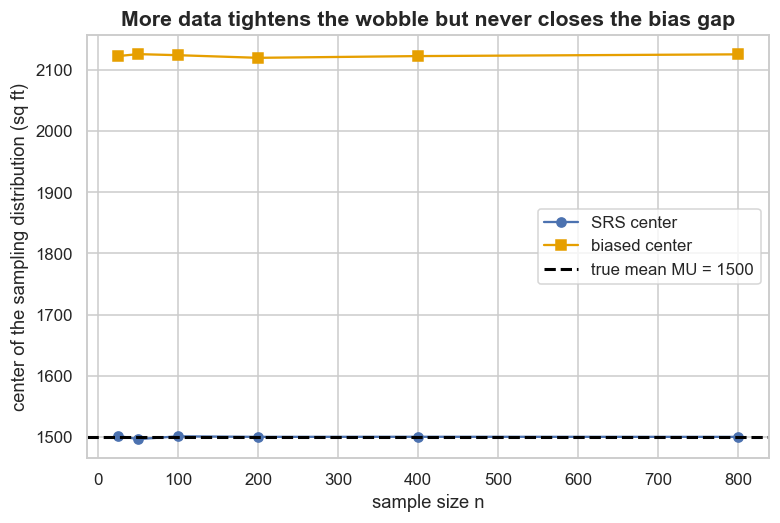

In [7]:
fig, ax = plt.subplots()
ax.plot(table['n'], table['SRS center'],    'o-', color='#4c72b0', label='SRS center')
ax.plot(table['n'], table['BIASED center'], 's-', color='#E69F00', label='biased center')
ax.axhline(MU, color='black', lw=2, ls='--', label=f'true mean MU = {MU:.0f}')
ax.set_xlabel('sample size n'); ax.set_ylabel('center of the sampling distribution (sq ft)')
ax.set_title('More data tightens the wobble but never closes the bias gap')
ax.legend(); plt.show()

Look at the **`BIASED spread`** column shrinking as $n$ grows — the random wobble *does* get
smaller. But **`BIASED still off by`** barely moves: the orange line stays stubbornly above the
truth at every sample size. With a biased method, a huge sample just makes you **confidently
wrong**. The famous real-world example is the *1936 Literary Digest poll*: 2.4 million responses,
and it still called the U.S. presidential election for the wrong candidate — partly because the
mailing list leaned on car and telephone owners (richer, not representative), and, just as
importantly, because only a self-selected slice mailed their ballots back (**nonresponse**, now
seen as the bigger culprit). Two million wrong is still wrong.

## 5) Types of bias, named — and where each one hides

Our simulation showed *selection on the variable* (big homes over-picked). In the wild, bias wears
several disguises. Each is just a different reason some members are systematically missing or
over-counted:

- **Convenience bias** — you sample whoever is easiest to reach (the homes near the office, the
  shoppers at one mall). *This is exactly our orange machine.*
- **Voluntary-response bias** — people *opt in*, so the angry and the passionate are
  over-represented (online star ratings, call-in polls).
- **Nonresponse bias** — you chose a good sample, but a *non-random slice refuses to answer*
  (busy people skip the survey), so who's left is skewed.
- **Undercoverage** — part of the population is left out of the sampling frame entirely (a phone
  survey misses people without phones — the Literary Digest's exact mistake).

Notice the thread: in **every** case, the *probability of being included depends on the very thing
you're measuring.* That's the fingerprint of bias — and the only cure is a sampling design where
inclusion is decided by **chance**, not by convenience or self-selection.

## 6) Two ways to learn from data: observe vs. experiment

So far we've talked about *measuring* a population. But often we want to know whether one thing
**causes** another. There are two research designs, and the difference decides what you're allowed
to conclude.

- **Observational study** — you *watch and record* without intervening (survey home sizes; track
  who drinks coffee and who gets cancer). Cheap and ethical, but it can only show **association**.
- **Experiment** — you *actively assign* treatments and compare outcomes (give group A the drug,
  group B a placebo). The only design that can establish **causation**.

Two pieces of vocabulary you'll use constantly:

- **Explanatory variable** (a.k.a. independent / predictor): the thing you suspect *does the
  causing* (coffee drinking).
- **Response variable** (a.k.a. dependent / outcome): the thing you measure to see the effect
  (cancer rate).

### The villain: confounding (a lurking variable)

A **confounder** is a *third* variable tangled up with both the explanatory and the response
variable, so you can't tell which one is really doing the work.

> Classic example: **ice-cream sales** are strongly correlated with **drownings**. Does ice cream
> cause drowning? No — **hot weather** is the lurking variable. It drives *both* up. Weather is
> *confounded* with ice cream.

In an **observational** study you can never fully rule confounders out — there's always one more
lurking variable you didn't think of. The fix is the subject of the next section.

## 7) Random SELECTION vs. random ASSIGNMENT — two jobs for chance

These sound alike and get mixed up constantly, but they buy you *two different things*. A great
study often wants both.

- **Random *selection*** — *how you get into the sample* (drawn at random from the population).
  → buys you **generalization**: results apply to the whole population. *(This is what Sections 3–5
  were about.)*
- **Random *assignment*** — *which treatment you get once you're in* (coffee or no coffee decided
  by a coin flip). → buys you **causation**: it balances confounders across the groups, so the only
  systematic difference between them is the treatment.

Why does random assignment tame confounders? Because chance spreads *every* lurking variable —
even ones you never measured or imagined — roughly evenly across the groups. Let's prove it with a
quick simulation: we'll randomly assign homes to a "treatment" and "control" group and check that a
confounder (here, **overall quality**) comes out **balanced**, with no effort on our part.

In [8]:
# A confounder we did NOT design around: overall quality (1-10 scale) of each home.
quality = ames['Overall.Qual'].to_numpy()
idx = np.arange(len(quality))

# Randomly assign every home to group A or B by a coin flip, many times over.
gapA_minus_B = []
for _ in range(2000):
    coin = rng.random(len(idx)) < 0.5      # True -> group A, False -> group B
    gapA_minus_B.append(quality[coin].mean() - quality[~coin].mean())
gapA_minus_B = np.array(gapA_minus_B)

print(f'Confounder = overall quality (population mean {quality.mean():.2f})')
print(f'Average quality gap A - B across 2,000 random assignments: {gapA_minus_B.mean():+.3f}')
print(f'  -> essentially 0: random assignment balances the confounder ON AVERAGE.')
print(f'Typical single-study gap (std): {gapA_minus_B.std():.3f} quality points  (shrinks with bigger groups)')

Confounder = overall quality (population mean 6.09)
Average quality gap A - B across 2,000 random assignments: -0.001
  -> essentially 0: random assignment balances the confounder ON AVERAGE.
Typical single-study gap (std): 0.053 quality points  (shrinks with bigger groups)


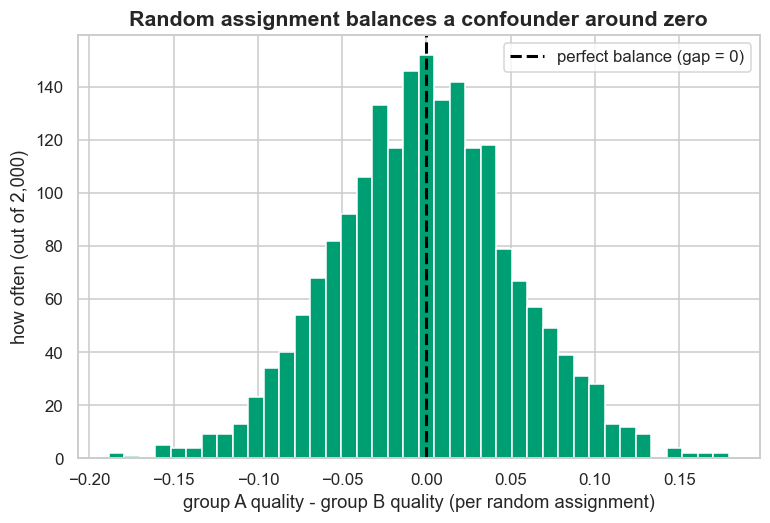

In [9]:
fig, ax = plt.subplots()
ax.hist(gapA_minus_B, bins=40, color='#009E73', edgecolor='white')
ax.axvline(0, color='black', lw=2, ls='--', label='perfect balance (gap = 0)')
ax.set_xlabel('group A quality - group B quality (per random assignment)')
ax.set_ylabel('how often (out of 2,000)')
ax.set_title('Random assignment balances a confounder around zero')
ax.legend(); plt.show()

- **The math:** under random assignment the *expected* difference in any pre-existing variable
  between groups is **0**. The histogram is centered on zero, exactly as predicted.
- **The meaning:** chance doesn't balance the confounder perfectly in *one* study (the cloud has
  width), but it does so **on average**, and — crucially — for *every* confounder at once, including
  the ones you never thought to measure.
- **The interpretation:** that's the superpower of a randomized experiment. Because the groups
  start out alike on everything *except* the treatment, any difference in the outcome can be pinned
  on the treatment — which is why we may finally say **"caused."**

## 8) The rest of good design (and a sober note)

Random assignment is the engine, but a few more parts make an experiment trustworthy:

- **Control group** — a baseline (placebo / no treatment) to compare against, so you can tell the
  treatment's effect from things that would have happened anyway.
- **Blinding** — keep subjects (single-blind) and ideally the researchers (double-blind) from
  knowing who got what, so expectations don't leak into the results (the *placebo effect* is real).
- **Replication** — repeat: many subjects per group, and ideally the *whole study* re-run by others.
  One study is a rumor; many agreeing studies are evidence.

**A note on the replication crisis (illustration, not advice).** In the 2010s, large efforts tried
to re-run famous published experiments and found that a sizable share **did not reproduce** —
the original effect vanished or shrank. Causes included small samples (lots of random wobble),
hidden bias, and *p-hacking* (trying many analyses and reporting only the flattering one). The
lesson isn't cynicism — it's that the unglamorous parts of this notebook (random selection, random
assignment, adequate sample size, replication) are exactly what separate a finding that lasts from
one that evaporates. Trustworthy data is *made*, on purpose, at collection time.

## Now you try

Predict first, then change one thing and re-run the cell:

1. **Does bias shrink with size?** In the Section-4 table cell, add a bigger size — change
   `sizes = [25, 50, 100, 200, 400, 800]` to `sizes = [25, 100, 800, 2000]`. Watch the
   **`BIASED still off by`** column: does pouring in data ever close the gap?
2. **Change the bias rule.** In Section 3, set `biased_mean(n, strength=3.0)` calls to use a
   *gentler* bias — edit the default to `strength=1.0`, then try `strength=6.0`. Does a stronger
   preference for big homes push the orange cloud further from $\mu$?
3. **Flip the direction of the bias.** Inside `biased_mean`, change `weights = population ** strength`
   to `weights = 1.0 / population ** strength` (favor *small* homes). Which side of $\mu$ does the
   biased cloud move to now?
4. **Watch the SRS cloud narrow.** In Section 3, change the `50` inside `srs_means = ... srs_mean(50)`
   to `srs_mean(400)` and re-plot. The blue cloud should get much **skinnier** but stay centered on
   $\mu$ — more data, less wobble, same (zero) bias.

## What you learned

- A **population** holds everyone you care about; a **sample** is what you measure. A **parameter**
  ($\mu$) describes the population (usually unknown); a **statistic** ($\bar{x}$) estimates it from a sample.
- A **simple random sample** gives everyone an equal chance and is **unbiased** — its sample means
  cluster right on the true mean. **Convenience / voluntary-response / nonresponse / undercoverage**
  all bias the sample by letting inclusion depend on the thing you're measuring.
- **Bias is a location problem, not a size problem:** a bigger sample shrinks the random wobble but
  leaves a biased method wrong on average — you just get *confidently* wrong.
- **Observational studies** show only association; **experiments** can show **causation**.
  **Confounders** (lurking variables) are the reason "correlation isn't causation."
- **Random selection** lets results **generalize** to the population; **random assignment** balances
  confounders to support **causal** claims — we watched it flatten a confounder to zero on average.
- **Control, blinding, and replication** are the rest of good design — and the replication crisis is
  a reminder that trustworthy data is *built on purpose* at collection time.

---

**← Previous:** [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 5: Probability & conditional probability](05-probability.ipynb)